In [1]:
import gc
import math
import random

import torchvision
from PIL import Image
from accelerate import Accelerator
from datasets import Dataset
from matplotlib import pyplot as plt
from torch import nn
from torch.optim.lr_scheduler import LinearLR, CosineAnnealingLR
from torchvision.transforms import transforms
from tensorboardX import SummaryWriter
from tqdm import tqdm
import torch
from diffusers import UNet2DModel, DDIMScheduler, DDPMScheduler

2024-07-13 10:13:25.955885: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-07-13 10:13:26.033662: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2024-07-13 10:13:26.114044: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-07-13 10:13:26.185955: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-07-13 10:13:26.186323: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1442] Unable to register cuBLAS factory: Attempting t

In [2]:
IMAGE_SIZE = 128  # 256
VECTOR_SIZE = 39
CLASS_EMB_SIZE = 16
MODEL_ID = "google/ddpm-celebahq-256"
DEVICE = "cuda"

N_EPOCHS = 2
BS = 3
LR = 1e-6

## Dataloader

In [29]:
dataset = Dataset.load_from_disk("../dataset/CelebA/celeba_vectors")

In [30]:
h = math.ceil(218 * (IMAGE_SIZE / 178))

preprocess = transforms.Compose(
    [
        transforms.Resize((h, IMAGE_SIZE)),
        transforms.CenterCrop((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5]),
    ]
)


def transform(examples):
    images = [
        preprocess(Image.open(f"../dataset/CelebA/img_align_celeba/{image}"))
        for image in examples["images"]
    ]
    return {"images": images, "vectors": torch.FloatTensor(examples["vectors"])}

Previewing batch:


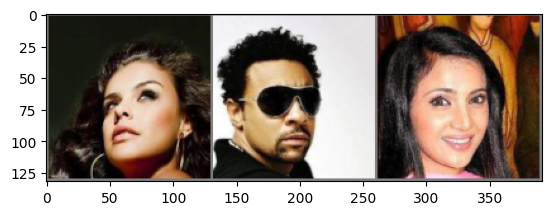

In [31]:
dataset.set_transform(transform)

train_dataloader = torch.utils.data.DataLoader(
    dataset, batch_size=BS, shuffle=True
)

print("Previewing batch:")
batch = next(iter(train_dataloader))
grid = torchvision.utils.make_grid(batch["images"], nrow=4)
plt.imshow(grid.permute(1, 2, 0).cpu().clip(-1, 1) * 0.5 + 0.5);

In [32]:
print(batch["images"].shape, batch["vectors"].shape)

torch.Size([3, 3, 128, 128]) torch.Size([3, 39])


## Unet

In [3]:
class ConditionedUnet(nn.Module):
    """
    https://huggingface.co/learn/diffusion-course/unit2/3
    """
    def __init__(
            self, 
            img_size=IMAGE_SIZE,
            num_classes=VECTOR_SIZE, 
            class_emb_size=CLASS_EMB_SIZE
    ):
        super().__init__()

        self.class_emb = nn.Sequential(
            nn.Dropout(0.1),  # 0.9
            nn.Linear(num_classes, class_emb_size),
            nn.SiLU()
        )
        self.add_cond = nn.Conv2d(3+class_emb_size, 3, kernel_size=1)            
        self.model = UNet2DModel(
            act_fn="silu",
            attention_head_dim=None,
            block_out_channels=(128, 128, 256, 256, 512, 512),
            center_input_sample=False,
            down_block_types=(
                "DownBlock2D",
                "DownBlock2D",
                "DownBlock2D",
                "DownBlock2D",
                "AttnDownBlock2D",
                "DownBlock2D",
            ),
            downsample_padding=0,
            flip_sin_to_cos=False,
            freq_shift=1,
            in_channels=3,
            layers_per_block=2,
            mid_block_scale_factor=1,
            norm_eps=1e-06,
            norm_num_groups=32,
            out_channels=3,
            sample_size=img_size,
            time_embedding_type="positional",
            up_block_types=(
                "UpBlock2D",
                "AttnUpBlock2D",
                "UpBlock2D",
                "UpBlock2D",
                "UpBlock2D",
                "UpBlock2D"
            ),
        )

    def forward(self, x, t, vectors=None):
        bs, ch, w, h = x.shape
        
        if vectors is not None:
            class_cond = self.class_emb(vectors)
            # (bs x 16)
            class_cond = class_cond.view(bs, class_cond.shape[1], 1, 1) \
                .expand(bs, class_cond.shape[1], w, h)
            # x is shape (bs, 3, 256, 256) and class_cond is now (bs, 16, 256, 256)
    
            net_input = torch.cat((x, class_cond), 1)  # (bs, 18, 256, 256)
            x = self.add_cond(net_input)

        # Feed this to the UNet alongside the timestep and return the prediction
        return self.model(x, t).sample  # (bs, 3, 256, 256)
    
    def init_weights(self, unet_state_dict):
        self.model.load_state_dict(unet_state_dict, strict=True)

In [4]:
cond_unet = ConditionedUnet()

state_dict = torch.load(
    "../../backend/weights/ddpm-celebahq-256/unet.pth"
)
cond_unet.init_weights(state_dict)
cond_unet = cond_unet.to(DEVICE)

#### Check

0it [00:00, ?it/s]

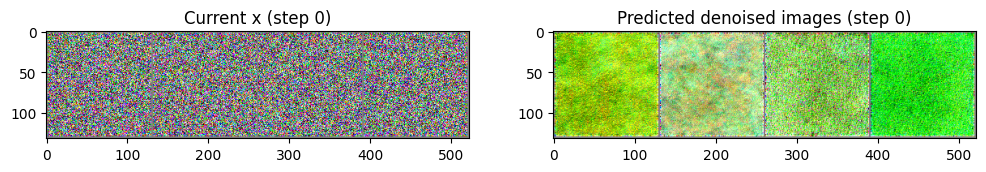

10it [00:03,  5.28it/s]

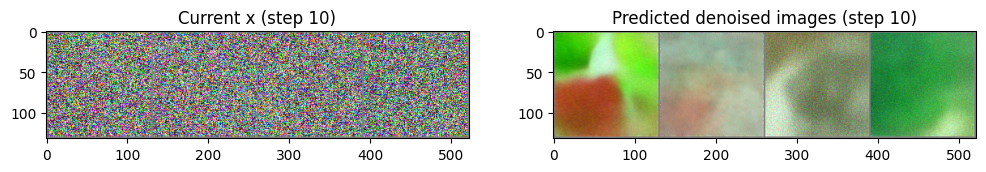

20it [00:04,  6.10it/s]

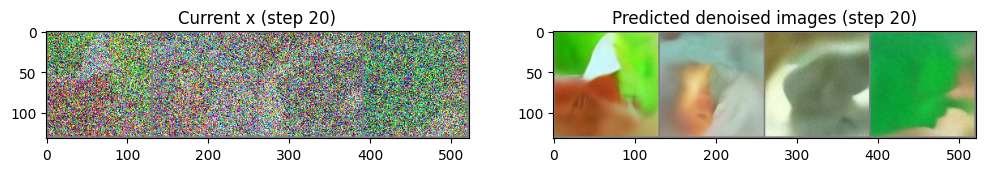

30it [00:06,  6.18it/s]

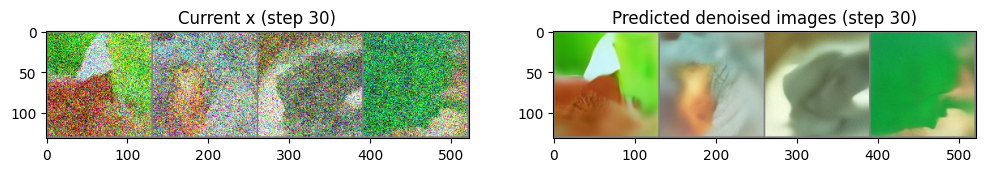

39it [00:08,  6.10it/s]

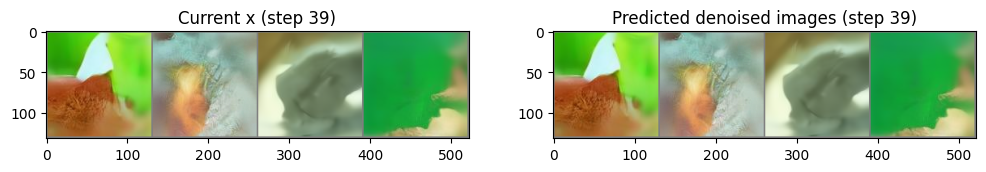

40it [00:08,  4.60it/s]


In [9]:
# unet = UNet2DModel.from_pretrained(MODEL_ID).to(DEVICE)
scheduler = DDIMScheduler.from_pretrained(MODEL_ID)
scheduler.set_timesteps(num_inference_steps=40)

x = torch.randn(4, 3, IMAGE_SIZE, IMAGE_SIZE).to(DEVICE)

# Loop through the sampling timesteps
for i, t in tqdm(enumerate(scheduler.timesteps)):

    # Prepare model input
    model_input = scheduler.scale_model_input(x, t)

    # Get the prediction
    with torch.no_grad():
        noise_pred = cond_unet(model_input, t)

    # Calculate what the updated sample should look like with the scheduler
    scheduler_output = scheduler.step(noise_pred, t, x)

    # Update x
    x = scheduler_output.prev_sample

    # Occasionally display both x and the predicted denoised images
    if i % 10 == 0 or i == len(scheduler.timesteps) - 1:
        fig, axs = plt.subplots(1, 2, figsize=(12, 5))

        grid = torchvision.utils.make_grid(x, nrow=4).permute(1, 2, 0)
        axs[0].imshow(grid.cpu().clip(-1, 1) * 0.5 + 0.5)
        axs[0].set_title(f"Current x (step {i})")

        pred_x0 = (
            scheduler_output.pred_original_sample
        )  # Not available for all schedulers
        grid = torchvision.utils.make_grid(pred_x0, nrow=4).permute(1, 2, 0)
        axs[1].imshow(grid.cpu().clip(-1, 1) * 0.5 + 0.5)
        axs[1].set_title(f"Predicted denoised images (step {i})")
        plt.show()

In [21]:
cond_unet = ConditionedUnet()
cond_unet.load_state_dict(torch.load("./runs/unet_63000_128.pth"))
cond_unet = cond_unet.to(DEVICE)

## Train

In [5]:
noise_scheduler = DDPMScheduler(
      beta_end=0.02,
      beta_schedule="linear",
      beta_start=0.0001,
      clip_sample=True,
      num_train_timesteps=1000,
      trained_betas=None,
      variance_type="fixed_small"
)
loss_fn = nn.MSELoss()
opt = torch.optim.Adam(cond_unet.parameters(), lr=LR)
# lr_scheduler = None
# lr_scheduler = LinearLR(opt)
lr_scheduler = CosineAnnealingLR(opt, T_max=5000)

In [34]:
model=cond_unet
device=DEVICE
dataloader=train_dataloader
optimizer=opt
criterion=loss_fn
n_epochs=N_EPOCHS
writer=None
losses = []

In [35]:
woman_vector = torch.FloatTensor([[
     1,  1, -1, -1, -1,  1,  0, -1,  1, -1,
    -1, -1, -1, -1, -1, -1, -1, -1,  1, -1,
    -1, -1, -1,  1, -1,  0,  1, -1, -1, -1,
     1,  0,  0, -1, -1,  1, -1, -1,  1
]])

man_vector = torch.FloatTensor([[
    -1,  1, -1, -1, -1, -1,  0,  1, -1, -1,
    -1,  1, -1, -1, -1, -1, -1, -1, -1,  1,
    -1,  1, -1,  1, -1, -1, -1, -1, -1,  1,
     0, -1,  1, -1, -1, -1, -1,  1,  0
]])

random_vector = torch.randint(low=-1, high=2, size=(1, VECTOR_SIZE)).type(torch.float32)
val_vector = torch.cat((random_vector, man_vector, woman_vector), dim=0)

In [36]:
def val(cond_unet, bs=3):
    # vector = torch.randint(low=-1, high=2, size=(bs, VECTOR_SIZE)).type(torch.float32).to(DEVICE)
    # vector[1, 19] = 1.
    # vector[2, 19] = -1.
    vector = val_vector.to(DEVICE)
            
    scheduler = DDIMScheduler.from_pretrained(MODEL_ID)
    scheduler.set_timesteps(num_inference_steps=40)
    x = torch.randn(bs, 3, IMAGE_SIZE, IMAGE_SIZE).to(DEVICE)
    
    for i, t in enumerate(scheduler.timesteps):
        model_input = scheduler.scale_model_input(x, t)
        with torch.no_grad():
            noise_pred = cond_unet(model_input, t, vector)
    
        scheduler_output = scheduler.step(noise_pred, t, x)
        x = scheduler_output.prev_sample
        grid = torchvision.utils.make_grid(x, nrow=bs).permute(1, 2, 0)

    return grid

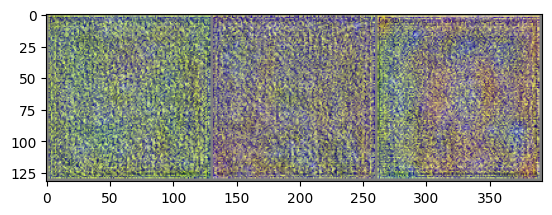

In [38]:
res = val(cond_unet)
plt.imshow(res.cpu().clip(-1, 1) * 0.5 + 0.5)

In [30]:
writer = SummaryWriter('./runs')

In [ ]:
%reload_ext tensorboard
%tensorboard --logdir ./runs

In [ ]:
for epoch in range(n_epochs):
    for index, batch in tqdm(enumerate(dataloader)):

        imgs = batch["images"].to(device)
        vecs = batch["vectors"].to(device)
        noise = torch.randn_like(imgs)
        timesteps = torch.randint(0, 999, (imgs.shape[0],)).long().to(device)
        noisy_img = noise_scheduler.add_noise(imgs, noise, timesteps)

        pred = model(noisy_img, timesteps, vecs)
        loss = criterion(pred, noise)

        loss.backward()

        # gradient_accumulation - все равно не помещается у меня на cuda для IMAGE_SIZE=256
        # if (index + 1) % gradient_accumulation_steps == 0:
        #     optimizer.step()
        #     optimizer.zero_grad()
        
        # Zero_grad лучше всего ставить именно
        # после step и до нового forward
        optimizer.step()
        if lr_scheduler is not None:
            lr_scheduler.step()
        optimizer.zero_grad()

        # Store the loss
        losses.append(loss.item())
        if index % 1000 == 0 and index > 0:
            avg_loss = sum(losses[-1000:]) / 1000
            print(f"{epoch}: Average of the last 1000 loss values: {avg_loss:05f}")
            torch.save(cond_unet.state_dict(), f"runs/unet_{index}_128.pth")
            grid = val(model)
            if writer is not None:
                writer.add_scalar('Loss/val', avg_loss, index)
                writer.add_image('Images/res', grid, index)
            else:
                plt.imsave(f"runs/val_{index}.png", (grid.cpu().clip(-1, 1) * 0.5 + 0.5).numpy())

1000it [09:54,  1.74it/s]

0: Average of the last 1000 loss values: 0.202207


2000it [19:49,  1.77it/s]

0: Average of the last 1000 loss values: 0.064028


3000it [29:30,  1.71it/s]

...

10000it [1:35:02,  1.82it/s]

0: Average of the last 1000 loss values: 0.027656


11000it [1:44:14,  1.81it/s]

0: Average of the last 1000 loss values: 0.024456


11907it [1:52:31,  1.84it/s]

In [ ]:
torch.save(cond_unet.state_dict(), f"runs/final_unet_128.pth")

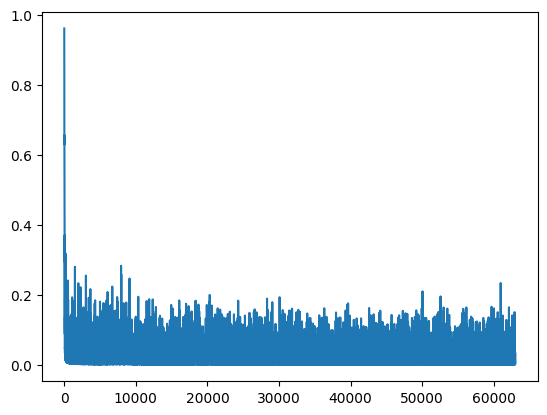

In [49]:
plt.plot(losses)

### Inference

In [6]:
props_dict = {
    "Изогнутые брови": {"pos": 0, "value": 1},    "Привлекательность": {"pos": 1, "value": 1},
    "Мешки под глазами": {"pos": 2, "value": 1},  "Лысый": {"pos": 3, "value": 1}, 
    "Челка": {"pos": 4, "value": 1},              "Большие губы": {"pos": 5, "value": 1}, 
    "Большой нос": {"pos": 6, "value": 1},        "Черные волосы": {"pos": 7, "value": 1}, 
    "Светлые волосы": {"pos": 8, "value": 1},     "Размытые": {"pos": 9, "value": 1}, 
    "Коричневые волосы": {"pos": 10, "value": 1}, "Густые брови": {"pos": 11, "value": 1},
    "Пухлость": {"pos": 12, "value": 1},          "Двойной подбородок": {"pos": 13, "value": 1}, 
    "Очки": {"pos": 14, "value": 1},              "Эспаньолка": {"pos": 15, "value": 1}, 
    "Седые волосы": {"pos": 16, "value": 1},      "Сильный макияж": {"pos": 17, "value": 1}, 
    "Высокие скулы": {"pos": 18, "value": 1},     "Мужчина": {"pos": 19, "value": 1}, 
    "Рот слегка открыт": {"pos": 20, "value": 1}, "Усы": {"pos": 21, "value": 1}, 
    "Узкие глаза": {"pos": 22, "value": 1},       "Без бороды": {"pos": 23, "value": 1}, 
    "Овальное лицо": {"pos": 24, "value": 1},     "Бледная кожа": {"pos": 25, "value": 1},
    "Острый нос": {"pos": 26, "value": 1},        "Залысины": {"pos": 27, "value": 1}, 
    "Розовые щеки": {"pos": 28, "value": 1},      "Бакенбарды": {"pos": 29, "value": 1},
    "Улыбчивость": {"pos": 30, "value": 1},       "Прямые волосы": {"pos": 31, "value": 1}, 
    "Волнистые волосы": {"pos": 32, "value": 1},  "В серьгах": {"pos": 33, "value": 1},
    "В шляпе": {"pos": 34, "value": 1},           "Губная помада": {"pos": 35, "value": 1}, 
    "Ожерелье": {"pos": 36, "value": 1},          "В галстуке": {"pos": 37, "value": 1}, 
    "Молодость": {"pos": 38, "value": 1},         "Прямые брови": {"pos": 0, "value": -1}, 
    "Узкие губы": {"pos": 5, "value": -1},        "Маленький нос": {"pos": 6, "value": -1},
    "Четкость": {"pos": 9, "value": -1},          "Редкие брови": {"pos": 11, "value": -1},
    "Стройность": {"pos": 12, "value": -1},       "Без макияжа": {"pos": 17, "value": -1}, 
    "Женщина": {"pos": 19, "value": -1},          "Широкие глаза": {"pos": 22, "value": -1},
    "Темная кожа": {"pos": 25, "value": -1},      "Грусть": {"pos": 30, "value": -1}, 
    "Старость": {"pos": 38, "value": -1},         "С бородой": {"pos": 23, "value": -1},
}

In [7]:
woman_vector = torch.FloatTensor([[
     1,  1, -1, -1, -1,  1,  0, -1,  1, -1,
    -1, -1, -1, -1, -1, -1, -1, -1,  1, -1,
    -1, -1, -1,  1, -1,  0,  1, -1, -1, -1,
     1,  0,  0, -1, -1,  1, -1, -1,  1
]])

man_vector = torch.FloatTensor([[
    -1,  1, -1, -1, -1, -1,  0,  1, -1, -1,
    -1,  1, -1, -1, -1, -1, -1, -1, -1,  1,
    -1,  1, -1,  1, -1, -1, -1, -1, -1,  1,
     0, -1,  1, -1, -1, -1, -1,  1,  0
]])

In [11]:
from typing import List

def run(prompts: List[str], scheduler, bs: int = 4):
    
    # vector = torch.zeros(bs, VECTOR_SIZE)
    if ("Мужчина" in prompts) or ("С бородой" in prompts) or \
       ("Усы" in prompts) or ("Лысый" in prompts) or \
       ("Залысины" in prompts) or ("Эспаньолка" in prompts) or \
       ("Бакенбарды" in prompts):
        vector = torch.cat([man_vector]*bs, dim=0)
    else:
        vector = torch.cat([woman_vector]*bs, dim=0)
        
    for prompt in prompts:
        item = props_dict.get(prompt)
        if item:
            for i in range(bs):
                vector[i, item["pos"]] = item["value"]
    vector = vector.to(DEVICE)
            
    x = torch.randn(bs, 3, IMAGE_SIZE, IMAGE_SIZE).to(DEVICE)
    
    for i, t in tqdm(enumerate(scheduler.timesteps)):
        model_input = scheduler.scale_model_input(x, t)
        with torch.no_grad():
            noise_pred = cond_unet(model_input, t, vector)
    
        scheduler_output = scheduler.step(noise_pred, t, x)
        x = scheduler_output.prev_sample
        grid = torchvision.utils.make_grid(x, nrow=bs).permute(1, 2, 0)
        

    return grid

In [36]:
cond_unet.load_state_dict(torch.load("./runs/best_14000_128.pth"))

<All keys matched successfully>

40it [00:10,  3.68it/s]


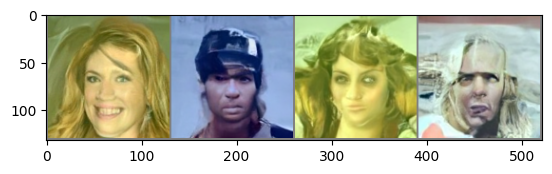

In [37]:
scheduler = DDIMScheduler.from_pretrained(MODEL_ID)
scheduler.set_timesteps(num_inference_steps=40)

res = run([], scheduler)
plt.imshow(res.cpu().clip(-1, 1) * 0.5 + 0.5)

80it [00:14,  5.65it/s]


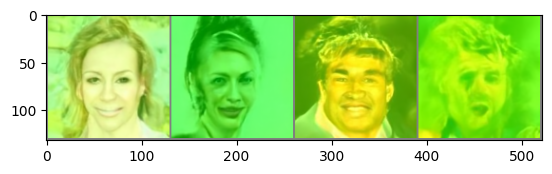

In [38]:
scheduler = noise_scheduler
scheduler.set_timesteps(num_inference_steps=80)

res = run([], scheduler)
plt.imshow(res.cpu().clip(-1, 1) * 0.5 + 0.5)

#### С Accelerate

In [ ]:
accelerator = Accelerator(gradient_accumulation_steps=2)
model, optimizer, train_dataloader, lr_scheduler = accelerator.prepare(
    model, optimizer, train_dataloader, lr_scheduler
)

for epoch in range(n_epochs):
    for batch in train_dataloader:
        with accelerator.accumulate(model):
            imgs = batch["images"].to(device)
            vecs = batch["vectors"].to(device)
            noise = torch.randn_like(imgs)
            timesteps = torch.randint(0, 999, (imgs.shape[0],)).long().to(device)
            noisy_img = noise_scheduler.add_noise(imgs, noise, timesteps)
    
            pred = model(noisy_img, timesteps, vecs)
            loss = criterion(pred, noise)
    
            accelerator.backward(loss)        
            # Zero_grad лучше всего ставить именно
            # после step и до нового forward
            optimizer.step()
            print("step")
            lr_scheduler.step()
            optimizer.zero_grad()
    
            # Store the loss
            losses.append(loss.item())
    
    avg_loss = sum(losses[-50:]) / 50
    print(f"{epoch}: Average of the last 50 loss values: {avg_loss:05f}")
    if writer is not None:
        writer.add_scalar('Loss/val', avg_loss, epoch)